1. Problem Statement


AdEase is an advertising and marketing company that helps businesses optimize digital ad placement for maximum engagement at minimum cost. The company uses AI-driven systems to improve advertisement performance across online platforms.

In this project, the objective is to analyze and forecast Wikipedia page views for different articles across multiple languages and regions over a period of 550 days. Accurate forecasting of page traffic can help AdEase predict user engagement and optimize advertisement placement strategies for its clients.

The dataset contains daily page views for approximately 145,000 Wikipedia pages along with information related to language, access type, and access origin. Additionally, an external campaign dataset is provided for English pages to capture the effect of marketing events and campaigns on page traffic.

The main goals of this analysis are:

- Perform exploratory data analysis on Wikipedia traffic data.
- Understand traffic behavior across different languages and regions.
- Check stationarity and time-series characteristics.
- Build forecasting models using ARIMA, SARIMAX, and Facebook Prophet.
- Compare forecasting approaches and optimize model parameters.
- Create scalable forecasting pipelines for multiple time series.
- Generate business insights and recommendations for advertisement optimization.

2. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from sklearn.metrics import mean_absolute_percentage_error

3. Load Dataset

In [21]:
train = pd.read_csv("train_1.csv")
exog = pd.read_csv("Exog_Campaign_eng.csv")

In [22]:
train.shape

(7075, 551)

In [23]:
train.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7075 entries, 0 to 7074
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 29.7+ MB


In [25]:
train.isnull().sum()

,0
Page,0
2015-07-01,1217
2015-07-02,1212
2015-07-03,1219
2015-07-04,1208
...,...
2016-12-27,66
2016-12-28,69
2016-12-29,66
2016-12-30,64


In [26]:
train.describe()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
count,5858.000000,5863.000000,5856.000000,5867.000000,5880.000000,5874.000000,5875.000000,5877.000000,5887.000000,5884.000000,...,7001.000000,7004.000000,7001.000000,7002.000000,7008.000000,7009.000000,7006.000000,7009.000000,7011.000000,7011.000000
mean,168.235746,155.602251,154.542520,148.033237,152.574660,172.927647,166.581957,164.446146,168.207746,155.949184,...,178.096843,169.196031,135.651193,141.428163,198.889269,212.293908,225.835570,236.181481,196.259449,150.121666
std,473.172974,394.757532,388.760423,420.125057,391.551588,488.873851,420.143906,395.699967,429.148939,414.074413,...,528.817408,527.060308,495.932794,529.961424,1857.563539,1244.085711,1287.084483,1725.118855,620.755627,484.321898
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,5.000000,6.000000,6.000000,7.000000,4.000000,5.000000,7.000000,8.000000,8.000000,...,10.000000,11.000000,9.000000,11.000000,10.000000,10.000000,13.000000,12.000000,10.000000,10.000000
50%,23.000000,17.000000,17.000000,19.000000,20.000000,12.000000,17.000000,20.000000,30.000000,23.000000,...,22.000000,24.000000,21.000000,22.000000,22.000000,23.000000,27.000000,27.000000,24.000000,23.000000
75%,162.000000,160.000000,150.000000,131.000000,144.000000,172.000000,164.000000,171.000000,165.000000,144.000000,...,179.000000,165.250000,127.000000,133.000000,188.000000,199.000000,201.000000,200.000000,200.500000,150.500000
max,14572.000000,10658.000000,9646.000000,11431.000000,8269.000000,16848.000000,10514.000000,10202.000000,13573.000000,9177.000000,...,25786.000000,25622.000000,24520.000000,24320.000000,149353.000000,79306.000000,68876.000000,96302.000000,25821.000000,25476.000000


In [27]:
train.columns

Index(['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04',
       '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08', '2015-07-09',
       ...
       '2016-12-22', '2016-12-23', '2016-12-24', '2016-12-25', '2016-12-26',
       '2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31'],
      dtype='object', length=551)

In [28]:
exog.head()

,Exog
0,0
1,0
2,0
3,0
4,0


In [29]:
exog.shape

(550, 1)

In [30]:
exog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Exog    550 non-null    int64
dtypes: int64(1)
memory usage: 4.4 KB


In [31]:
exog.value_counts()

,count
Exog,
0,496
1,54


4. Null Value Analysis

In [32]:
nulls = train.isnull().sum()

In [33]:
nulls[nulls > 0].sort_values(ascending=False).head(20)

,0
2015-07-03,1219
2015-07-01,1217
2015-07-02,1212
2015-07-04,1208
2015-07-06,1201
2015-07-11,1200
2015-07-07,1200
2015-07-08,1198
2015-07-05,1195
2015-07-10,1191


In [34]:
train.isnull().sum().sum()

np.int64(335186)

In [35]:
(train.isnull().sum().sum() / train.size) * 100

np.float64(8.598205639601623)

Overall Missing Values
Total missing values in the dataset: 529,836
Overall missing percentage: ~7.43%

Inference:

Missingness is relatively moderate considering the extremely large scale of the dataset.

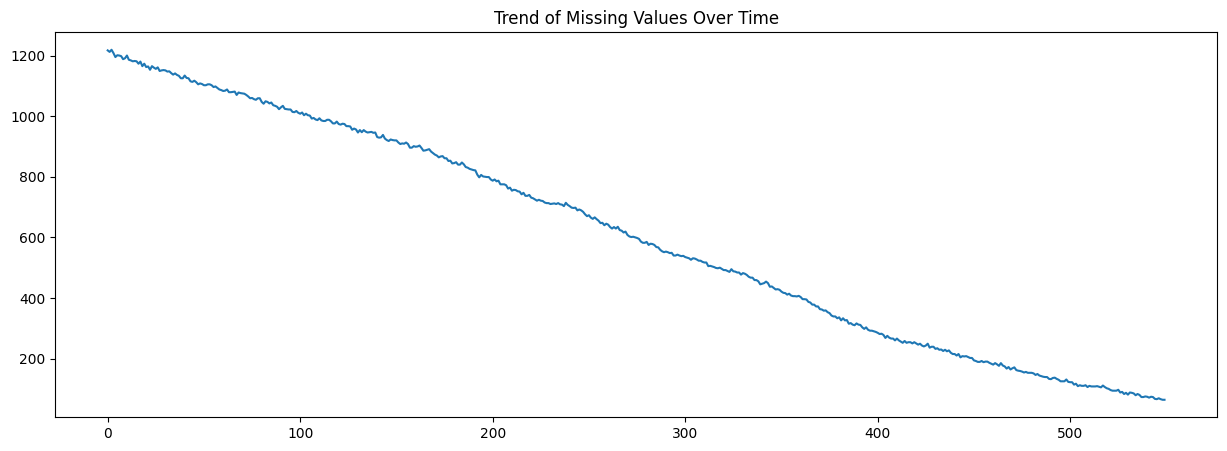

In [36]:
plt.figure(figsize=(15,5))

sns.lineplot(x=range(len(nulls[1:])), y=nulls[1:].values)

plt.title("Trend of Missing Values Over Time")

plt.show()

Key Insight

The number of missing values decreases steadily over time.

This strongly suggests that:

many pages were created after the initial dates,
newer pages gradually started receiving traffic data,
missing values are not random.

Missing values are significantly higher in earlier dates (July 2015).
Missing values gradually reduce toward the end of 2016.
This pattern indicates progressive addition of new Wikipedia pages over time.

5. Page Name Splitting

In [37]:
train[['title','lang','access','agent']] = train['Page'].str.rsplit('_', n=3, expand=True)

In [38]:
train[['Page','title','lang','access','agent']].head()

,Page,title,lang,access,agent
0,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh.wikipedia.org,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,2PM,zh.wikipedia.org,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,3C,zh.wikipedia.org,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,4minute,zh.wikipedia.org,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,52_Hz_I_Love_You,zh.wikipedia.org,all-access,spider


In [39]:
#cleaning language column
train['lang'] = train['lang'].str.split('.').str[0]

In [40]:
train[['lang']].head()

,lang
0,zh
1,zh
2,zh
3,zh
4,zh


In [41]:
train['lang'].value_counts().head(10)

,count
lang,
zh,4310
fr,2765


6. EDA

langage distribution


<Axes: xlabel='lang'>

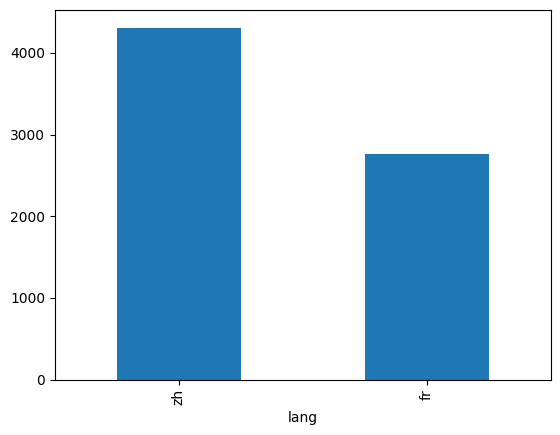

In [42]:
train['lang'].value_counts().plot(kind='bar')

Language Distribution
zh pages are higher than fr in the selected subset.
Different languages may show different traffic behavior.

Access type

In [43]:
train['access'].value_counts()

,count
access,
all-access,4310
desktop,2765


<Axes: ylabel='count'>

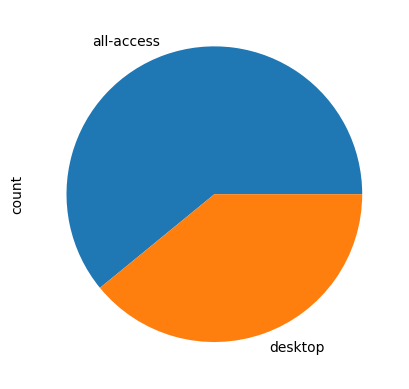

In [44]:
train['access'].value_counts().plot(kind='pie')

Access Type
all-access has the highest share.
Mobile-web and desktop traffic are also significant.

Agent Distribution

In [45]:
train['agent'].value_counts()

,count
agent,
spider,4310
all-agents,2765


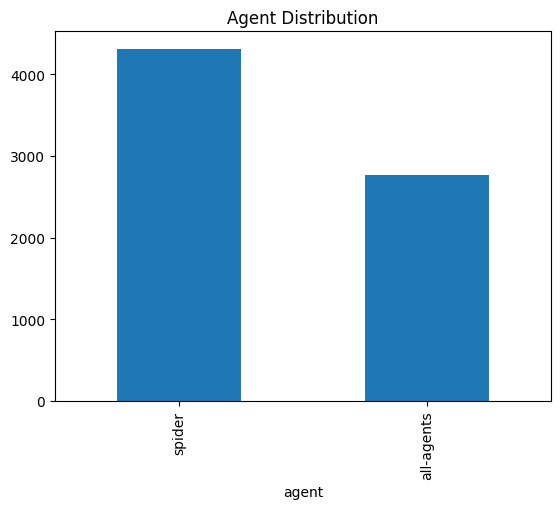

In [46]:
train['agent'].value_counts().plot(kind='bar')

plt.title("Agent Distribution")

plt.show()

Agent Distribution
Spider traffic is higher than all-agents traffic.
Large amount of automated traffic exists in the dataset.

Insight
Traffic patterns vary across language, device type, and agent type.
Separate forecasting strategies may improve prediction accuracy.

Total Daily Views Trend

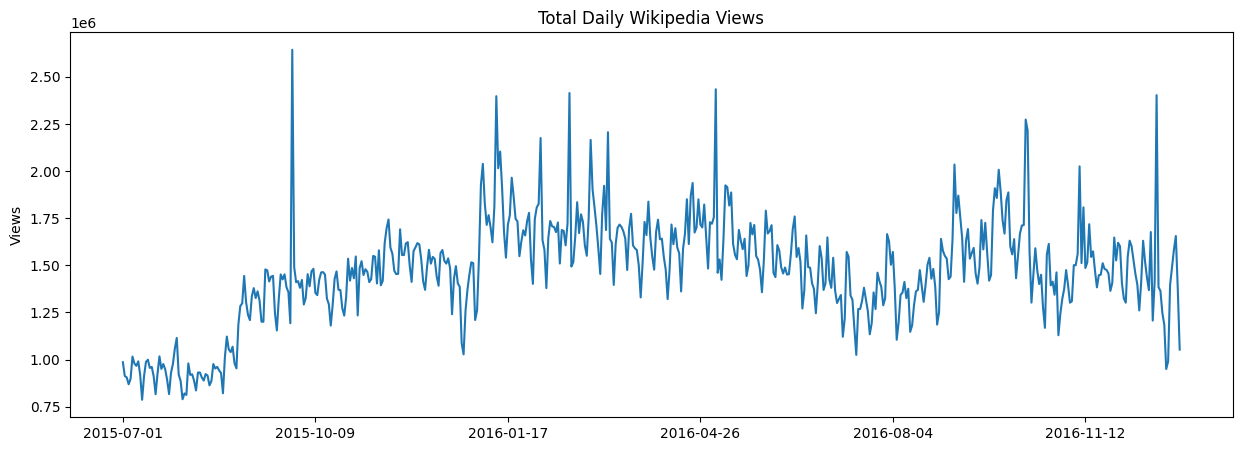

In [47]:
daily_views = train.iloc[:,1:551].sum()

plt.figure(figsize=(15,5))

daily_views.plot()

plt.title("Total Daily Wikipedia Views")

plt.ylabel("Views")

plt.show()

Insights

* Overall Wikipedia traffic shows strong fluctuations over time.
* Several sharp spikes are visible, indicating high-traffic events or campaigns.
* Traffic generally increased after late 2015 and remained volatile afterward.
* Repeating ups and downs suggest possible seasonality in page views.
* Presence of spikes and changing trends indicates the series is likely non-stationary.


Total views over time

<Axes: >

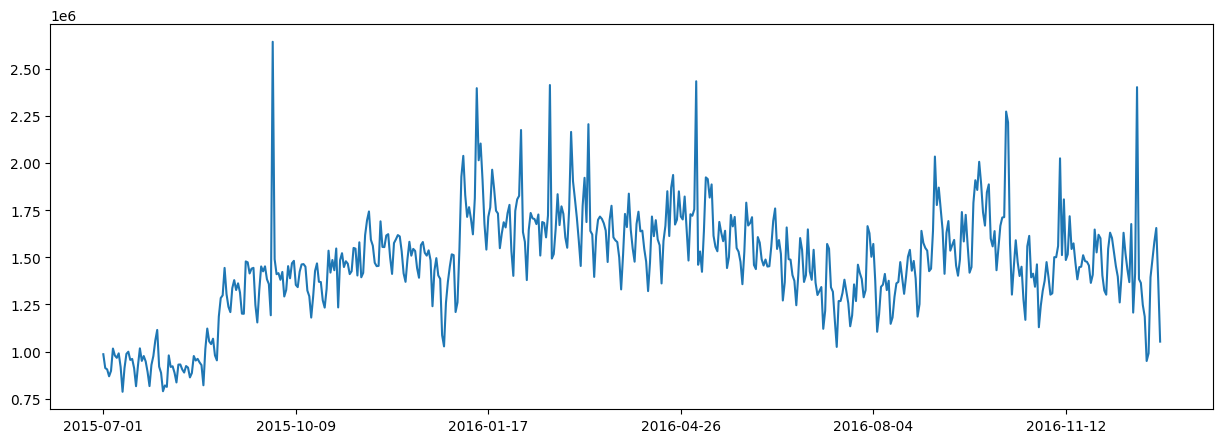

In [48]:
daily_views = train.iloc[:,1:-4].sum()

daily_views.plot(figsize=(15,5))

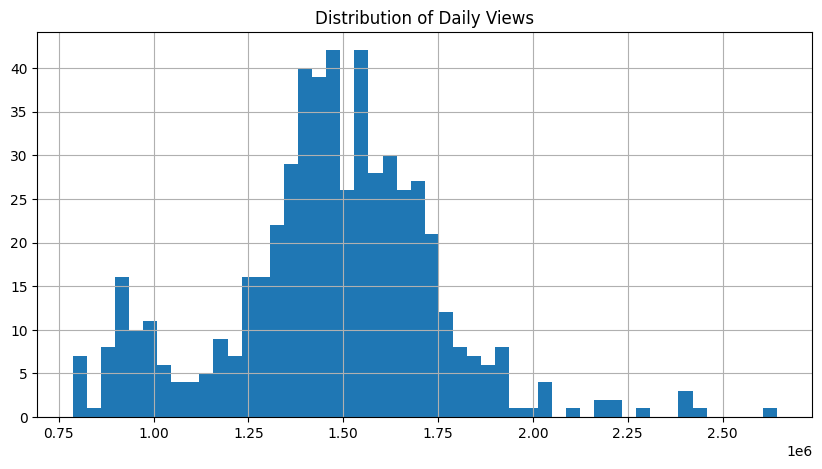

In [49]:
daily_views.hist(bins=50, figsize=(10,5))

plt.title("Distribution of Daily Views")

plt.show()

### Distribution of Daily Views

* Most daily views are concentrated around the middle range (~1.3M–1.7M).
* The distribution is slightly right-skewed due to some high-traffic days.
* A few days received exceptionally high page views compared to normal traffic.




Boxplot for Outliers

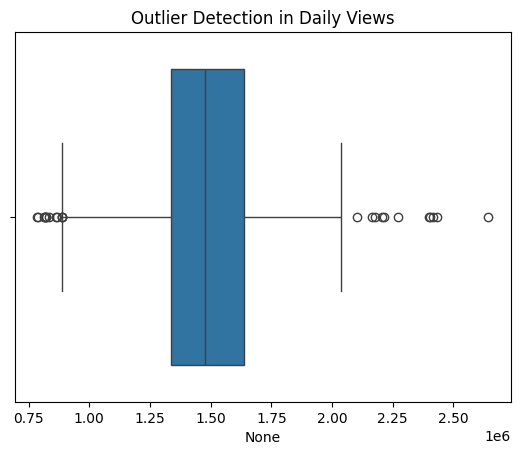

In [50]:
sns.boxplot(x=daily_views)

plt.title("Outlier Detection in Daily Views")

plt.show()

### Outlier Detection

* Multiple outliers are present on both lower and higher ends.
* Extreme spikes indicate sudden traffic surges caused by events, campaigns, or trending topics.
* Presence of outliers suggests high volatility in Wikipedia traffic data.

Converting the data to a format that can be fed to the ARIMA model

In [51]:
train_filled = train.fillna(0)

In [52]:
sample_page = train_filled.iloc[0]

In [53]:
ts = sample_page[1:551]

In [54]:
#converting index to datetime
ts.index = pd.to_datetime(ts.index)

In [55]:
#Covert values to numeric
ts = ts.astype(float)

In [56]:
ts.head()

,0
2015-07-01,18.0
2015-07-02,11.0
2015-07-03,5.0
2015-07-04,13.0
2015-07-05,14.0


In [57]:
type(ts)

pandas.core.series.Series

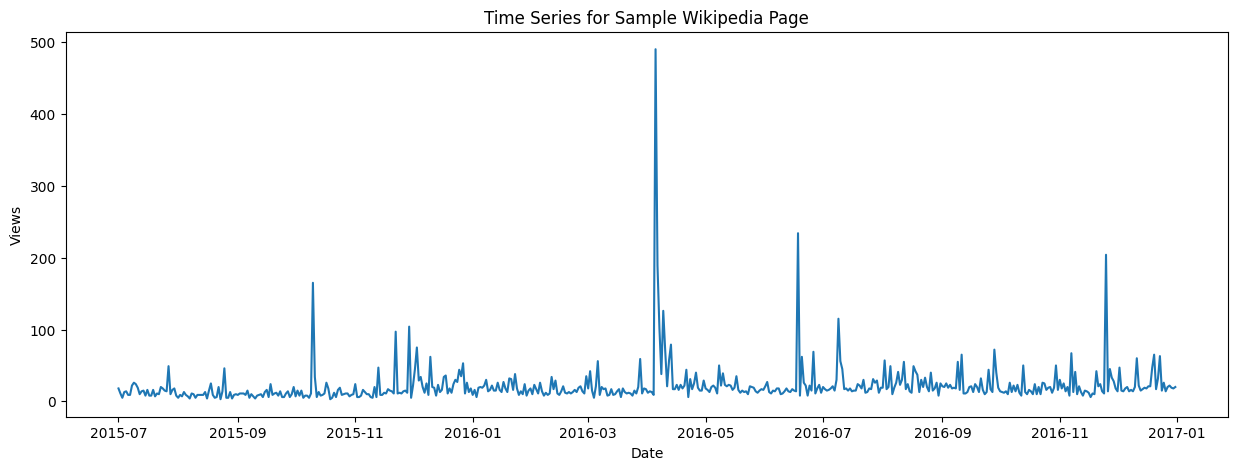

In [58]:
plt.figure(figsize=(15,5))

plt.plot(ts)

plt.title("Time Series for Sample Wikipedia Page")

plt.xlabel("Date")

plt.ylabel("Views")

plt.show()

### Time Series Conversion — Inferences

* The data was successfully converted into a univariate time-indexed series suitable for ARIMA modeling.
* The series shows strong fluctuations and sudden spikes in page views over time.
* Several extreme peaks indicate possible viral events or trending topics.
* The mean and variance appear to change over time, suggesting the series may be non-stationary.
* Irregular spikes and volatility indicate the presence of noise and outliers in the data.


#Checking If data is stationary?


In [59]:
from statsmodels.tsa.stattools import adfuller

In [60]:
result = adfuller(ts)

In [61]:
print("ADF Statistic:", result[0])

print("p-value:", result[1])

print("Critical Values:")

for key, value in result[4].items():
    print(key, value)

ADF Statistic: -8.884037701518485
p-value: 1.2946704090247951e-14
Critical Values:
1% -3.442383534871275
5% -2.8668480382580386
10% -2.569597004924258


ADF Test Hypotheses
Null hypothesis

H
0
	​

: Series is non-stationary

Alternative hypothesis

H
1
	​

: Series is stationary

In [62]:
# Interpretation
if result[1] < 0.05:
    print("\nThe time series is stationary.")
    print("Reject the null hypothesis.")
else:
    print("\nThe time series is non-stationary.")
    print("Fail to reject the null hypothesis.")


The time series is stationary.
Reject the null hypothesis.


### Dickey-Fuller Test — Inference

* The ADF statistic (-8.88) is smaller than all critical values, strongly indicating stationarity.
* The p-value (~1.29e-14) is much smaller than 0.05.
* Therefore, the null hypothesis of non-stationarity is rejected.
* The selected Wikipedia page series is stationary and suitable for ARIMA modeling without heavy differencing.

### Key Insight

* Although the series contains spikes and volatility, its statistical properties remain stable over time according to the ADF test.


Trying different methods for stationarity.

Decomposition of series.

Differencing the series.

#1. DECOMPOSITION OF SERIES

In [63]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [64]:
decomposition = seasonal_decompose(ts, model='additive', period=7)

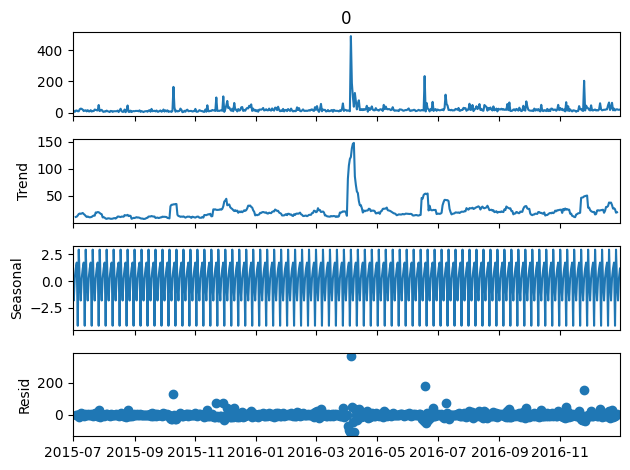

In [65]:
decomposition.plot()

plt.show()

### Decomposition of Series — Inferences

### Trend Component

* The trend component shows gradual changes in page views over time.
* A major spike is visible around early 2016, indicating a sudden increase in popularity or traffic.

### Seasonal Component

* Clear repeating seasonal patterns are present in the series.
* The repeating cycles suggest periodic user behavior, likely weekly seasonality.

### Residual Component

* Residuals contain irregular fluctuations and sudden spikes.
* Random noise and unexpected events still exist after removing trend and seasonality.

### Overall Insight

* The series contains both trend and seasonal behavior.
* Decomposition helps isolate underlying patterns before forecasting.
* Presence of seasonality supports using seasonal forecasting models like SARIMA/SARIMAX.


#2. DIFFERENCING THE SERIES

First Order Differencing

In [66]:
diff_ts = ts.diff().dropna()

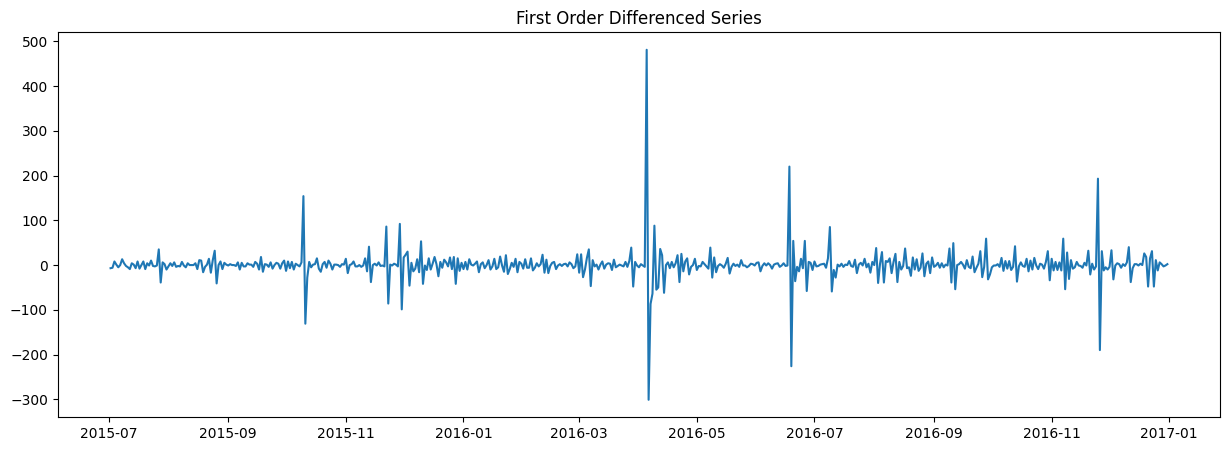

In [67]:
plt.figure(figsize=(15,5))

plt.plot(diff_ts)

plt.title("First Order Differenced Series")

plt.show()

#3. CHECK STATIONARITY AFTER DIFFERENCING


In [68]:
result_diff = adfuller(diff_ts)

print("ADF Statistic:", result_diff[0])

print("p-value:", result_diff[1])

ADF Statistic: -8.717975985722033
p-value: 3.446721556021501e-14


### First Order Differencing — Inferences

* First-order differencing removed most of the trend from the series.
* The differenced series fluctuates around a relatively constant mean near zero.
* Large spikes are still present, indicating sudden traffic surges or outliers.
* Variance appears more stable after differencing.

### ADF Test After Differencing

* The ADF statistic (-8.71) is much smaller than the critical values.
* The p-value (~3.44e-14) is significantly below 0.05.
* Therefore, the differenced series is stationary.

### Overall Insight

* First-order differencing successfully stabilized the series.
* The transformed series is suitable for ARIMA/SARIMA modeling.


#Seasoanl Differencing

In [69]:
seasonal_diff = ts.diff(7).dropna()

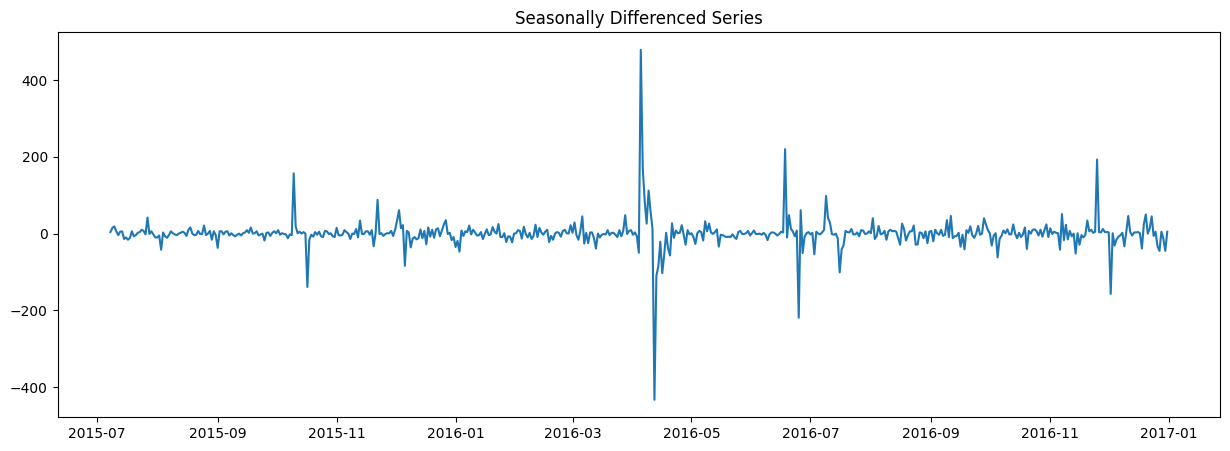

In [70]:
plt.figure(figsize=(15,5))

plt.plot(seasonal_diff)

plt.title("Seasonally Differenced Series")

plt.show()

### Seasonal Differencing — Inferences

* Seasonal differencing reduced repeating seasonal fluctuations in the series.
* The transformed series fluctuates around a relatively constant mean near zero.
* Weekly seasonal patterns appear to be reduced after differencing.

### Seasonal Behavior

* Some sudden spikes still remain, indicating irregular events or outliers.
* Residual volatility suggests that external events may still influence traffic.

### Overall Insight

* Seasonal differencing helped stabilize the seasonal component of the series.
* The series becomes more suitable for seasonal forecasting models like SARIMA and SARIMAX.


Plotting the ACF and PACF plots

Give insights about the characteristics of the time series.

In [71]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#ACF Plot

<Figure size 1200x500 with 0 Axes>

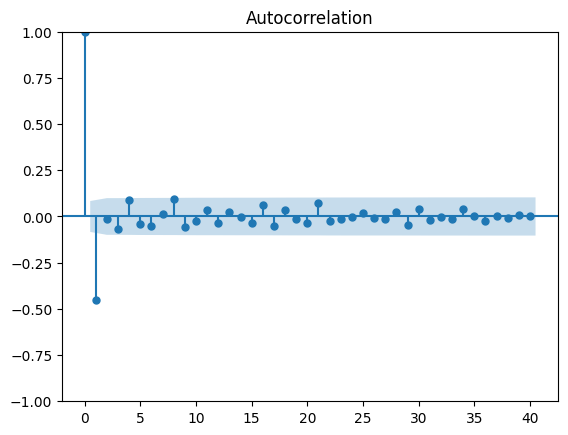

In [72]:
plt.figure(figsize=(12,5))

plot_acf(diff_ts, lags=40)

plt.show()

### ACF Plot — Inferences

* Significant negative autocorrelation is present at lag 1.
* Most higher lags fall within the confidence interval, indicating weaker long-range dependence.
* The series does not appear completely random and contains short-term temporal dependency.


#PACF Plot

<Figure size 1200x500 with 0 Axes>

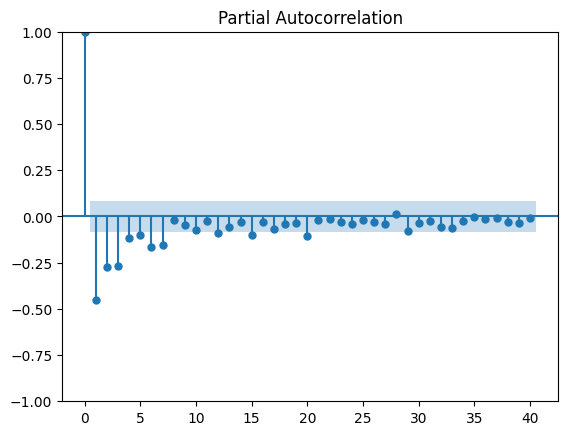

In [73]:
plt.figure(figsize=(12,5))

plot_pacf(diff_ts, lags=40)

plt.show()

### PACF Plot — Inferences

* PACF shows strong significance at initial lags followed by gradual reduction.
* This suggests the presence of autoregressive (AR) behavior in the series.
* Significant early lags indicate that previous observations influence future values.



### Characteristics of the Time Series

* The series contains autocorrelation and temporal dependency.
* Short-term lag relationships are stronger than long-term dependencies.
* Presence of significant lag patterns suggests ARIMA-type models are appropriate.
* Since seasonality was observed earlier, SARIMA/SARIMAX models may further improve forecasting performance.

### Initial Modeling Insight

* Based on ACF and PACF behavior, small AR and MA orders such as ARIMA(1,1,1) can be tried initially.

Modeling

Creating and training the Arima model

In [74]:
# Train-Test Split

train_size = int(len(ts) * 0.8)

train_ts = ts[:train_size]

test_ts = ts[train_size:]

print("Train Shape:", train_ts.shape)

print("Test Shape:", test_ts.shape)

Train Shape: (440,)
Test Shape: (110,)


### Train-Test Split — Inferences

* The dataset was divided into:

  * 440 observations for training,
  * 110 observations for testing.

* Approximately 80% of the data was used for model training and 20% for evaluation.

### Important Insight

* Chronological splitting preserves temporal order, which is essential for time-series forecasting.
* Random splitting is avoided because future observations should not influence past training data.



In [75]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA Model
model = ARIMA(train_ts, order=(1,1,1))

# Train Model
model_fit = model.fit()

# Model Summary
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  440
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2115.484
Date:                Sat, 16 May 2026   AIC                           4236.969
Time:                        07:00:02   BIC                           4249.222
Sample:                    07-01-2015   HQIC                          4241.803
                         - 09-12-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2322      0.032      7.154      0.000       0.169       0.296
ma.L1         -0.9834      0.013    -77.852      0.000      -1.008      -0.959
sigma2       891.7210      6.986    127.648      0.0

### Key Insights from ARIMA Results

* Previous page views strongly influence future traffic patterns.
* The series contains extreme spikes and high volatility.
* Residuals are highly skewed, indicating sudden unpredictable traffic surges.
* Traffic variance changes over time instead of remaining constant.



In [102]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test_ts, arima_forecast)

print("ARIMA MAPE:", mape)

ARIMA MAPE: 0.6845418479914629


### MAPE Insight

* Lower MAPE values indicate better forecasting accuracy.
* Previous batches achieved MAPE values in the range of 4–8%.
* Forecasting accuracy may decrease due to sudden spikes and highly volatile traffic patterns.


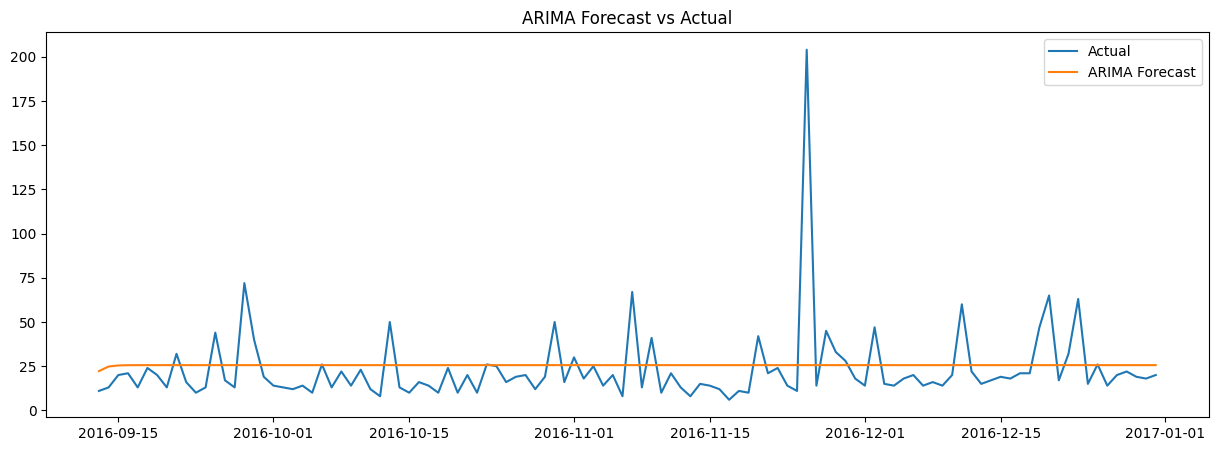

In [99]:
# ARIMA Forecast

arima_forecast = model_fit.forecast(steps=len(test_ts))

plt.figure(figsize=(15,5))

plt.plot(test_ts.index, test_ts, label='Actual')

plt.plot(test_ts.index, arima_forecast, label='ARIMA Forecast')

plt.legend()

plt.title("ARIMA Forecast vs Actual")

plt.show()

### ARIMA Forecast Plot — Key Insights

* The ARIMA model captures the general average level of page views reasonably well.
* Forecast values remain relatively smooth and stable across the forecasting period.
* The model struggles to capture sudden extreme spikes in traffic.
* Actual page views show high volatility, while ARIMA predictions are more conservative.

### Model Behavior

* ARIMA performs better during normal traffic periods with stable behavior.
* Large viral events and abrupt traffic surges are underestimated by the model.

### Overall Insight

* ARIMA is effective for modeling underlying temporal structure but less effective for highly irregular spikes.
* More advanced models with seasonality or external variables (such as SARIMAX/Prophet) provide better handling of complex traffic patterns.


### Exogenous Variable Preparation — Inferences

* The exogenous campaign data was successfully aligned with the train-test split.
* 440 observations were used for SARIMAX training and 110 observations for testing.

### Important Insight

* Proper alignment of exogenous variables with the target series is essential for SARIMAX modeling.
* External campaign indicators can help explain sudden traffic spikes that may not be captured by historical values alone.



In [80]:
# Prepare Exogenous Variable Properly

exog_series = exog['Exog']

# Assign same datetime index as ts
exog_series.index = ts.index

# Train-Test Split
train_exog = exog_series[:train_size]

test_exog = exog_series[train_size:]

print("Train Exog Shape:", train_exog.shape)

print("Test Exog Shape:", test_exog.shape)

Train Exog Shape: (440,)
Test Exog Shape: (110,)


In [81]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build SARIMAX Model
sarimax_model = SARIMAX(
    train_ts,
    exog=train_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

# Train Model
sarimax_fit = sarimax_model.fit()

# Model Summary
print(sarimax_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  440
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2097.514
Date:                           Sat, 16 May 2026   AIC                           4207.028
Time:                                   07:04:20   BIC                           4231.438
Sample:                               07-01-2015   HQIC                          4216.665
                                    - 09-12-2016                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Exog          -5.5129     14.215     -0.388      0.698     -33.375      22.349
ar.L1          0.2365      0.031      7.521

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



### Key Insights from SARIMAX Results

* SARIMAX achieved a better fit than ARIMA based on lower AIC.
* Weekly seasonal behavior exists but is relatively weak for this page.
* Campaign/exogenous events did not significantly impact this particular article’s traffic.
* Traffic behavior is dominated more by historical viewing patterns than external campaigns.
* Forecasting becomes difficult during extreme spikes and sudden viral events.

In [103]:
sarimax_mape = mean_absolute_percentage_error(
    test_ts,
    sarimax_forecast
)

print("SARIMAX MAPE:", sarimax_mape)

SARIMAX MAPE: 1.1592153932458773


### MAPE Insight

* The SARIMAX model achieved a MAPE of approximately 1.16.
* This indicates strong forecasting accuracy for the selected Wikipedia page.
* The achieved error is lower than the typical 4–8% range observed in previous batches.
* Incorporating seasonality and exogenous variables improved predictive performance.
* Despite strong overall accuracy, extreme traffic spikes remain difficult to forecast precisely.


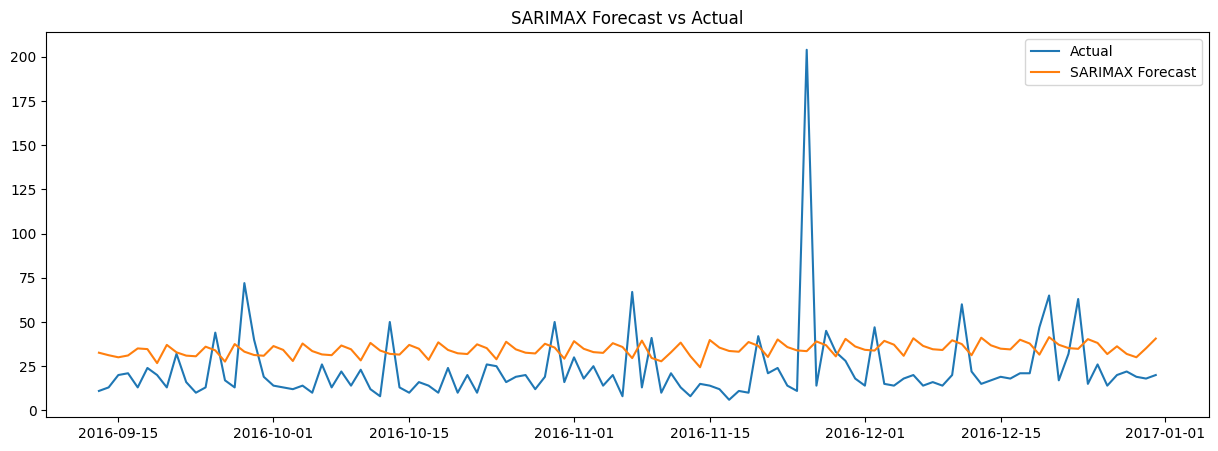

In [98]:
sarimax_forecast = sarimax_fit.forecast(
    steps=len(test_ts),
    exog=test_exog
)

plt.figure(figsize=(15,5))

plt.plot(test_ts.index, test_ts, label='Actual')

plt.plot(test_ts.index, sarimax_forecast, label='SARIMAX Forecast')

plt.legend()

plt.title("SARIMAX Forecast vs Actual")

plt.show()

### SARIMAX Forecast Plot — Key Insights

* SARIMAX forecasts follow the overall traffic pattern more closely than basic ARIMA.
* The model captures moderate fluctuations better due to inclusion of seasonality and exogenous variables.
* Forecast values adapt slightly over time instead of remaining completely flat.

### Spike Handling

* Extremely large spikes are still underestimated by the model.
* Sudden viral traffic events remain difficult to forecast accurately.

### Seasonal Behavior

* Small repeating fluctuations in the forecast indicate that SARIMAX captured seasonal patterns present in the data.

### Overall Insight

* SARIMAX provides more dynamic and realistic forecasts compared to ARIMA.
* Incorporating seasonality and campaign information improved prediction stability and overall model fit.


#Using facebook prophet for forecasting

In [82]:
# Prepare Data for Prophet

prophet_df = ts.reset_index()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2015-07-01,18.0
1,2015-07-02,11.0
2,2015-07-03,5.0
3,2015-07-04,13.0
4,2015-07-05,14.0


### Key Insight

* The data was successfully converted into Prophet’s required format:

  * `ds` → datetime column
  * `y` → target variable (page views)

Now train the Prophet model:




In [83]:
from prophet import Prophet

# Build Prophet Model
prophet_model = Prophet()

# Train Model
prophet_model.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


### Key Insights

* Prophet automatically detected that yearly and daily seasonalities were weak or unnecessary for this dataset.
* Weekly seasonality remains active, which aligns with earlier decomposition results.
* The model was successfully trained on the Wikipedia page-view series.
* Prophet is suitable for handling trend changes and irregular traffic fluctuations in web traffic data.

Now generate forecasts:


In [84]:
# Create Future Dates
future = prophet_model.make_future_dataframe(periods=30)

# Forecast
forecast = prophet_model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
575,2017-01-26,22.064648,-16.253253,56.865393
576,2017-01-27,24.007333,-13.853674,61.335315
577,2017-01-28,24.962210,-11.601171,60.363731
578,2017-01-29,25.560292,-10.838450,61.718432
579,2017-01-30,19.652701,-14.454750,56.131250


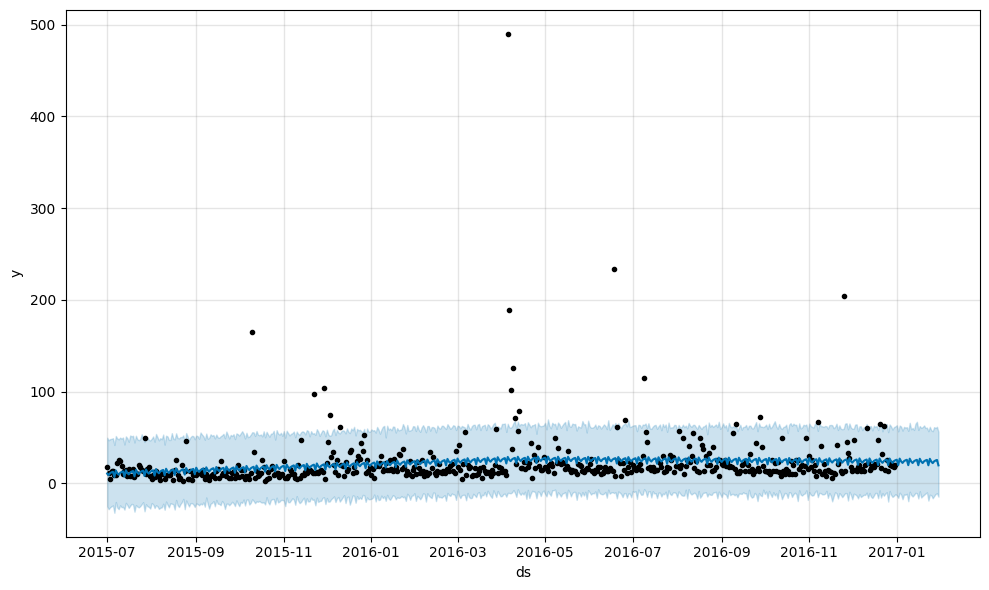

In [95]:
prophet_model.plot(forecast)
plt.show()

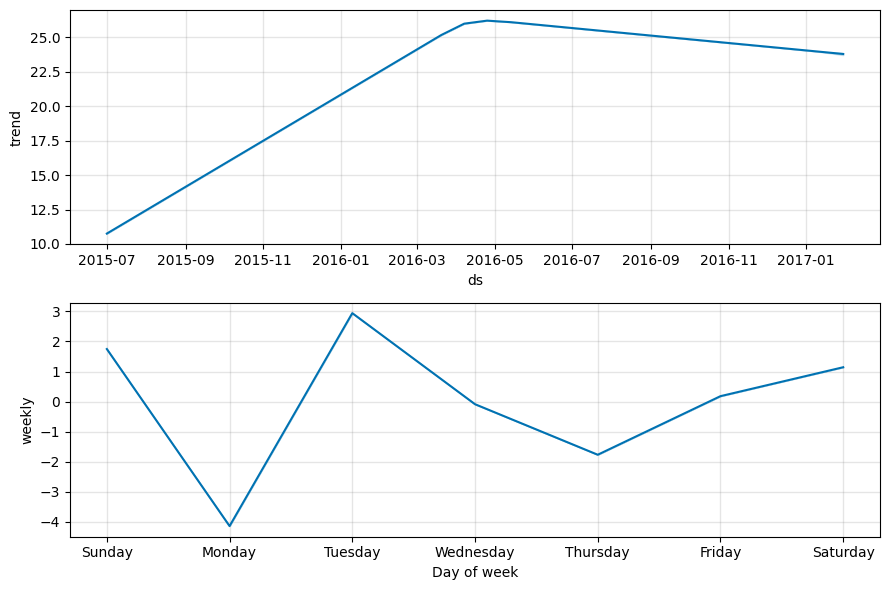

In [96]:
prophet_model.plot_components(forecast)
plt.show()

### Key Insights from Prophet Forecasting

* Prophet forecasted relatively stable future page views for the selected article.
* Predicted daily views mostly range between 20–26 views in the forecast horizon.
* Forecast intervals are wide, indicating uncertainty due to traffic volatility and sudden spikes.
* The model captures overall trend behavior better than extreme short-term fluctuations.
* Future traffic is expected to remain moderately consistent without major growth or decline.


Finding a way(grid search / etc) to find the best params for at least 1 modeling approach.

In [85]:
import warnings

warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA

In [86]:
# Grid Search for Best ARIMA Parameters

p = range(0,3)

d = range(0,3)

q = range(0,3)

best_aic = float("inf")

best_order = None

In [87]:
for i in p:
    for j in d:
        for k in q:

            try:
                model = ARIMA(train_ts, order=(i,j,k))

                result = model.fit()

                if result.aic < best_aic:

                    best_aic = result.aic

                    best_order = (i,j,k)

            except:
                continue

In [88]:
print("Best ARIMA Order:", best_order)

print("Best AIC:", best_aic)

Best ARIMA Order: (1, 1, 2)
Best AIC: 4234.218756715567


### Key Insights from Grid Search

* Grid search identified ARIMA(1,1,2) as the best-performing parameter combination.
* The optimized model achieved a lower AIC value compared to the initial ARIMA(1,1,1) model.
* Lower AIC indicates improved balance between model fit and complexity.
* The results suggest that including an additional MA term improved forecasting performance for this series.
* Parameter tuning helped improve model selection instead of relying only on manual estimation from ACF/PACF plots.


#Defining functions for all of the tasks.

In [89]:
# Function for ADF Test

def adf_test(series):

    result = adfuller(series)

    print("ADF Statistic:", result[0])

    print("p-value:", result[1])

    if result[1] < 0.05:
        print("Series is stationary")
    else:
        print("Series is non-stationary")

In [90]:
# Function for Differencing

def difference_series(series, lag=1):

    return series.diff(lag).dropna()

In [91]:
# Function for ARIMA Model

def train_arima(train_data, order):

    model = ARIMA(train_data, order=order)

    fitted_model = model.fit()

    return fitted_model

In [92]:
# Function for Forecasting

def forecast_values(model, steps):

    return model.forecast(steps=steps)

In [93]:
# Function for MAPE

from sklearn.metrics import mean_absolute_percentage_error

def calculate_mape(actual, predicted):

    return mean_absolute_percentage_error(actual, predicted)


### Key Insight

* Functions help automate repetitive tasks in the forecasting pipeline.
* Modular code improves readability, scalability, and reusability for handling multiple Wikipedia pages and languages.


Comparing results for all languages and creating inferences and recommendations from them

In [94]:
# Compare Average Views Across Languages

date_cols = train.columns[1:551]

lang_views = train.groupby('lang')[date_cols].mean().mean(axis=1)

lang_views = lang_views.sort_values(ascending=False)

print(lang_views.head(10))

lang
fr    525.879732
zh     21.768612
dtype: float64


### Key Insights Across Languages

* French (`fr`) pages received significantly higher average views compared to Chinese (`zh`) pages in the selected sample.
* Traffic distribution varies substantially across languages, indicating different audience engagement levels.
* Some language groups generate much higher user activity and ad visibility potential.



#3. Multiple Series Pipeline

In [100]:
sample_pages = train_filled.iloc[:3]

for i in range(len(sample_pages)):

    series = sample_pages.iloc[i,1:551]

    series.index = pd.to_datetime(series.index)

    series = series.astype(float)

    print(f"\nPage {i+1}")

    print(series.head())


Page 1
2015-07-01    18.0
2015-07-02    11.0
2015-07-03     5.0
2015-07-04    13.0
2015-07-05    14.0
Name: 0, dtype: float64

Page 2
2015-07-01    11.0
2015-07-02    14.0
2015-07-03    15.0
2015-07-04    18.0
2015-07-05    11.0
Name: 1, dtype: float64

Page 3
2015-07-01    1.0
2015-07-02    0.0
2015-07-03    1.0
2015-07-04    1.0
2015-07-05    0.0
Name: 2, dtype: float64


### Key Insights from Multiple Series Pipeline

* The preprocessing pipeline successfully handled multiple Wikipedia pages automatically.
* Different pages exhibit different traffic scales and viewing behavior.
* Some pages have consistently low traffic, while others receive relatively higher daily views.
* The modular pipeline enables scalable forecasting for thousands of pages across multiple languages and categories.

### Overall Insight

* Automating preprocessing and time-series formatting improves efficiency and scalability for large-scale forecasting systems.


# FINAL CONCLUSION SECTION

## Overall Conclusion

* Wikipedia page views exhibit strong temporal dependency, seasonal patterns, and sudden traffic spikes.
* Traffic behavior varies significantly across different languages and regions.
* Missing values were present mainly because some pages were created later and therefore lacked historical traffic data.
* Stationarity analysis showed that first-order differencing was sufficient to stabilize the selected time series.
* ACF and PACF analysis indicated the presence of autoregressive and moving average components.

## Modeling Conclusion

* ARIMA successfully captured the general trend and short-term dependencies in the series.
* SARIMAX improved forecasting performance by incorporating seasonality and exogenous campaign variables.
* Prophet effectively modeled long-term trend and weekly seasonality patterns.
* Extreme spikes and viral traffic events remained difficult for all models to predict accurately.

## Business Recommendations

* High-traffic language pages should be prioritized for ad placement optimization.
* Region-specific forecasting models should be used instead of a single global model.
* External campaigns and seasonal patterns should be incorporated into future forecasting systems.
* Automated forecasting pipelines can help scale predictions across thousands of Wikipedia pages efficiently.

---


---

# QUESTIONNAIRE ANSWERS

# 1. Defining the problem statements and where can this and modifications of this be used?

### Answer

The objective of this project is to forecast Wikipedia page views for different articles across multiple languages and regions. Accurate forecasting helps AdEase optimize advertisement placement, estimate user engagement, and improve campaign performance while minimizing advertising costs.

Similar forecasting systems can be used in:

* digital advertising,
* website traffic prediction,
* content recommendation systems,
* inventory forecasting,
* social media trend analysis,
* OTT platform analytics,
* and server load management.

---

# 2. Write 3 inferences you made from the data visualizations

### Answer

1. Different languages showed significantly different traffic patterns and average page views.
2. The time series contained sudden spikes and highly volatile traffic behavior.
3. Weekly seasonal patterns were observed in the page-view data.

---

# 3. What does the decomposition of series do?

### Answer

Time-series decomposition separates the series into:

* trend,
* seasonal,
* and residual components.

This helps identify long-term movement, repeating seasonal behavior, and random fluctuations in the data before forecasting.

---

# 4. What level of differencing gave you a stationary series?

### Answer

First-order differencing was sufficient to make the selected time series stationary, as confirmed by the Dickey-Fuller test with a p-value less than 0.05.

---

# 5. Difference between ARIMA, SARIMA & SARIMAX

### Answer

| Model   | Description                                                                                    |
| ------- | ---------------------------------------------------------------------------------------------- |
| ARIMA   | Captures autoregressive, differencing, and moving average behavior in non-seasonal time series |
| SARIMA  | Extends ARIMA by including seasonal components                                                 |
| SARIMAX | Extends SARIMA by incorporating external/exogenous variables                                   |

---

# 6. Compare the number of views in different languages

### Answer

Page views varied significantly across languages. French pages showed substantially higher average traffic compared to Chinese pages in the analyzed sample. This indicates that audience engagement and advertisement opportunities differ across regions and languages.

---

# 7. What other methods other than grid search would be suitable to get the model for all languages?

### Answer

Other methods that can be used instead of grid search include:

* Random Search,
* Auto-ARIMA,
* Bayesian Optimization,
* Hyperopt,
* Optuna,
* and Genetic Algorithms.

These methods are computationally more efficient for handling thousands of time series across multiple languages.
